# Experiment 40 — Full Long-Horizon Relevance → Downstream Utility Bridge

This analysis directly connects the two main empirical parts of the paper at the **same horizons**:

\[
H\in\{96,192,336,720\}.
\]

The predictive-relevance results are frozen from Experiment 39. The downstream strong-forecaster
results are loaded from the protocol-locked Experiment 37 condition table.

## Main question

Does better historical relevance imply better forecasting utility?

The intended answer is **not necessarily**. The bridge analysis tests this directly at the
dataset–horizon level.

### Important interpretation

- There are 24 dataset–horizon points, but they are **not 24 independent datasets**.
- Correlations are therefore descriptive.
- The strongest evidence comes from structured contrasts:
  - Solar / Weather: relevance improvement and positive downstream utility.
  - ETTh1: relevance improves at every horizon, but downstream utility is adverse.
  - Exchange: candidate-global relevance dominates and downstream calibration largely abstains.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 240)

DATASETS = [
    "ETTh1",
    "Weather",
    "Electricity",
    "Traffic",
    "Exchange",
    "Solar",
]

HORIZONS = [96, 192, 336, 720]

BACKBONES = [
    "PatchTST",
    "iTransformer",
    "TimeMixer",
    "SegMoE",
]

ROOT_CANDIDATES = [
    Path("/data/dataset/strong_forecaster"),
    Path("/data/strong_forecaster"),
]

ROOT = next((p for p in ROOT_CANDIDATES if p.exists()), None)

if ROOT is None:
    raise FileNotFoundError(
        "Could not find strong_forecaster root. Tried:\n"
        + "\n".join(f" - {p}" for p in ROOT_CANDIDATES)
    )

OUT_DIR = ROOT / "full_long_horizon_relevance_downstream_bridge"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("OUT_DIR:", OUT_DIR)


ROOT: /data/dataset/strong_forecaster
OUT_DIR: /data/dataset/strong_forecaster/full_long_horizon_relevance_downstream_bridge


## 1. Frozen Experiment 39 relevance results

`AnalogFutureMSE` is lower-is-better.

The primary bridge variable is

\[
\text{RetrievalGain}(\%) =
100\frac{\text{Pattern}-\text{Learned}}{\text{Pattern}}.
\]

`QuerySpecificGain` is the improvement of Learned over the within-channel Shuffled-Future control.

`PriorGain` is the improvement of Candidate Prior over Pattern. We use it as a descriptive diagnostic here; the bridge analysis does not require a binary significance label for this axis.

These controls allow us to keep the regime analysis separate from the downstream forecasting result.


In [2]:
rows = [
    # Dataset, H, Pattern, Prior, Learned, Shuffled, Sig Pattern->Learned, Sig Shuffled->Learned
    ('ETTh1', 96, 1.195878, 1.2183, 0.995375, 1.387354, True, True),
    ('ETTh1', 192, 1.383055, 1.292313, 1.160534, 1.537791, True, True),
    ('ETTh1', 336, 1.556203, 1.356678, 1.332749, 1.610606, True, True),
    ('ETTh1', 720, 1.737053, 1.490594, 1.532154, 1.78954, True, True),

    ('Weather', 96, 0.913355, 0.25785, 0.806514, 0.627484, True, False),
    ('Weather', 192, 0.962618, 0.320045, 0.877885, 0.786918, True, False),
    ('Weather', 336, 1.100516, 0.406713, 0.980122, 0.968104, True, False),
    ('Weather', 720, 1.273764, 0.524525, 1.157938, 1.140886, True, False),

    ('Electricity', 96, 0.477137, 0.41176, 0.392364, 0.554495, True, True),
    ('Electricity', 192, 0.482181, 0.417895, 0.408721, 0.550554, True, True),
    ('Electricity', 336, 0.513699, 0.440371, 0.442422, 0.57982, True, True),
    ('Electricity', 720, 0.58904, 0.50018, 0.519661, 0.667902, True, True),

    ('Traffic', 96, 0.875554, 0.905708, 0.863432, 1.092021, False, True),
    ('Traffic', 192, 0.883992, 0.914254, 0.869169, 1.084658, True, True),
    ('Traffic', 336, 0.910878, 0.940618, 0.894336, 1.102242, True, True),
    ('Traffic', 720, 0.97161, 0.998918, 0.948603, 1.137833, True, True),

    ('Exchange', 96, 0.211965, 0.098876, 0.201246, 0.199855, False, False),
    ('Exchange', 192, 0.424098, 0.228619, 0.414987, 0.423465, False, True),
    ('Exchange', 336, 0.769549, 0.469822, 0.823094, 0.79739, False, False),
    ('Exchange', 720, 1.894643, 1.514171, 2.06649, 1.935582, False, False),

    ('Solar', 96, 0.666227, 1.016373, 0.471276, 1.316049, True, True),
    ('Solar', 192, 0.64461, 0.990156, 0.498956, 1.434488, True, True),
    ('Solar', 336, 0.693457, 1.072159, 0.526908, 1.547378, True, True),
    ('Solar', 720, 0.726212, 1.165314, 0.56462, 1.607708, True, True),
]

rel = pd.DataFrame(
    rows,
    columns=[
        "Dataset",
        "Horizon",
        "Pattern",
        "CandidatePrior",
        "Learned",
        "Shuffled",
        "Sig_RetrievalGain",
        "Sig_QuerySpecificGain",
    ],
)

rel["RetrievalGain_pct"] = (
    (rel["Pattern"] - rel["Learned"])
    / rel["Pattern"]
    * 100.0
)

rel["QuerySpecificGain_pct"] = (
    (rel["Shuffled"] - rel["Learned"])
    / rel["Shuffled"]
    * 100.0
)

rel["PriorGain_pct"] = (
    (rel["Pattern"] - rel["CandidatePrior"])
    / rel["Pattern"]
    * 100.0
)

display(rel)

print(
    "Learned beats Pattern:",
    int((rel["RetrievalGain_pct"] > 0).sum()),
    "/",
    len(rel),
)

print(
    "Significant Pattern->Learned:",
    int(rel["Sig_RetrievalGain"].sum()),
    "/",
    len(rel),
)


,Dataset,Horizon,Pattern,CandidatePrior,Learned,Shuffled,Sig_RetrievalGain,Sig_QuerySpecificGain,RetrievalGain_pct,QuerySpecificGain_pct,PriorGain_pct
0,ETTh1,96,1.195878,1.218300,0.995375,1.387354,True,True,16.766175,28.253712,-1.874940
1,ETTh1,192,1.383055,1.292313,1.160534,1.537791,True,True,16.089093,24.532397,6.560983
2,ETTh1,336,1.556203,1.356678,1.332749,1.610606,True,True,14.358924,17.251705,12.821271
3,ETTh1,720,1.737053,1.490594,1.532154,1.789540,True,True,11.795783,14.382802,14.188341
4,Weather,96,0.913355,0.257850,0.806514,0.627484,True,False,11.697642,-28.531405,71.768918
5,Weather,192,0.962618,0.320045,0.877885,0.786918,True,False,8.802349,-11.559908,66.752647
6,Weather,336,1.100516,0.406713,0.980122,0.968104,True,False,10.939777,-1.241396,63.043427
7,Weather,720,1.273764,0.524525,1.157938,1.140886,True,False,9.093207,-1.494628,58.820865
8,Electricity,96,0.477137,0.411760,0.392364,0.554495,True,True,17.767015,29.239398,13.701935
9,Electricity,192,0.482181,0.417895,0.408721,0.550554,True,True,15.234943,25.761869,13.332338


Learned beats Pattern: 22 / 24
Significant Pattern->Learned: 19 / 24


## 2. Load Experiment 37 downstream condition table


In [3]:
preferred = (
    ROOT
    / "four_backbone_dataset_meta_analysis"
    / "condition_level_selected.csv"
)

if preferred.is_file():
    condition_csv = preferred
else:
    hits = sorted(ROOT.rglob("condition_level_selected.csv"))

    if not hits:
        raise FileNotFoundError(
            "Could not find condition_level_selected.csv. "
            "Run Experiment 37 v3 first."
        )

    hits = sorted(
        hits,
        key=lambda p: (
            0 if "four_backbone_dataset_meta_analysis" in str(p) else 1,
            len(p.parts),
            str(p),
        ),
    )

    condition_csv = hits[0]

print("Using:", condition_csv)

conditions = pd.read_csv(condition_csv)

required = {
    "Dataset",
    "Backbone",
    "Horizon",
    "MSEGain_pct",
}

missing = required - set(conditions.columns)

if missing:
    raise ValueError(
        f"Missing required columns: {sorted(missing)}"
    )

down = conditions[
    conditions["Dataset"].isin(DATASETS)
    & conditions["Backbone"].isin(BACKBONES)
    & conditions["Horizon"].astype(int).isin(HORIZONS)
].copy()

coverage = (
    down.groupby(["Dataset", "Horizon"])
    ["Backbone"]
    .nunique()
    .reindex(
        pd.MultiIndex.from_product(
            [DATASETS, HORIZONS],
            names=["Dataset", "Horizon"],
        )
    )
)

display(coverage.rename("N_Backbones").reset_index())

if not bool((coverage == 4).all()):
    raise RuntimeError(
        "Downstream coverage is incomplete.\n"
        + str(coverage)
    )

print("PASS: 24 dataset-horizon cells × 4 backbones = 96 downstream conditions.")


Using: /data/dataset/strong_forecaster/four_backbone_dataset_meta_analysis/condition_level_selected.csv


,Dataset,Horizon,N_Backbones
0,ETTh1,96,4
1,ETTh1,192,4
2,ETTh1,336,4
3,ETTh1,720,4
4,Weather,96,4
5,Weather,192,4
6,Weather,336,4
7,Weather,720,4
8,Electricity,96,4
9,Electricity,192,4


PASS: 24 dataset-horizon cells × 4 backbones = 96 downstream conditions.


## 3. Aggregate downstream utility at the dataset–horizon level

The primary downstream variable is the mean MSE improvement across the four forecasting backbones.

We also retain the number of wins/losses/ties so that a mean improvement cannot hide architecture
instability.


In [4]:
down_rows = []

for dataset in DATASETS:
    for H in HORIZONS:
        grp = down[
            (down["Dataset"] == dataset)
            & (down["Horizon"].astype(int) == H)
        ].copy()

        row = {
            "Dataset": dataset,
            "Horizon": H,
            "DownstreamMeanGain_pct": float(grp["MSEGain_pct"].mean()),
            "DownstreamMedianGain_pct": float(grp["MSEGain_pct"].median()),
            "DownstreamWins": int((grp["MSEGain_pct"] > 0).sum()),
            "DownstreamLosses": int((grp["MSEGain_pct"] < 0).sum()),
            "DownstreamTies": int((grp["MSEGain_pct"].abs() <= 1e-12).sum()),
        }

        for backbone in BACKBONES:
            bb = grp[grp["Backbone"] == backbone]

            if len(bb) != 1:
                raise RuntimeError(
                    f"Expected one row for {dataset}/{H}/{backbone}; found {len(bb)}."
                )

            row[f"{backbone}_Gain_pct"] = float(
                bb.iloc[0]["MSEGain_pct"]
            )

        down_rows.append(row)

down_h = pd.DataFrame(down_rows)

bridge = rel.merge(
    down_h,
    on=["Dataset", "Horizon"],
    how="inner",
    validate="one_to_one",
)

display(
    bridge[
        [
            "Dataset",
            "Horizon",
            "RetrievalGain_pct",
            "QuerySpecificGain_pct",
            "PriorGain_pct",
            "DownstreamMeanGain_pct",
            "DownstreamWins",
            "DownstreamTies",
            "DownstreamLosses",
        ]
    ]
)

bridge.to_csv(
    OUT_DIR / "full_24point_bridge.csv",
    index=False,
)


,Dataset,Horizon,RetrievalGain_pct,QuerySpecificGain_pct,PriorGain_pct,DownstreamMeanGain_pct,DownstreamWins,DownstreamTies,DownstreamLosses
0,ETTh1,96,16.766175,28.253712,-1.874940,-0.803750,0,0,4
1,ETTh1,192,16.089093,24.532397,6.560983,-1.510031,0,0,4
2,ETTh1,336,14.358924,17.251705,12.821271,-1.767803,0,0,4
3,ETTh1,720,11.795783,14.382802,14.188341,-5.725651,0,0,4
4,Weather,96,11.697642,-28.531405,71.768918,2.004451,4,0,0
5,Weather,192,8.802349,-11.559908,66.752647,2.534369,4,0,0
6,Weather,336,10.939777,-1.241396,63.043427,2.720022,4,0,0
7,Weather,720,9.093207,-1.494628,58.820865,2.844704,4,0,0
8,Electricity,96,17.767015,29.239398,13.701935,0.796260,4,0,0
9,Electricity,192,15.234943,25.761869,13.332338,0.537338,4,0,0


## 4. Descriptive association

Because four horizons are repeated within each dataset, the 24 points are clustered.
We therefore report correlations as **descriptive summaries only**, not as independent-sample
hypothesis tests.

The six dataset means are also reported separately.


In [5]:
def corr_summary(df, label):
    return {
        "Level": label,
        "N": len(df),
        "Pearson_Retrieval_vs_Downstream": float(
            df["RetrievalGain_pct"].corr(
                df["DownstreamMeanGain_pct"],
                method="pearson",
            )
        ),
        "Spearman_Retrieval_vs_Downstream": float(
            df["RetrievalGain_pct"].corr(
                df["DownstreamMeanGain_pct"],
                method="spearman",
            )
        ),
        "Pearson_QuerySpecific_vs_Downstream": float(
            df["QuerySpecificGain_pct"].corr(
                df["DownstreamMeanGain_pct"],
                method="pearson",
            )
        ),
        "Spearman_QuerySpecific_vs_Downstream": float(
            df["QuerySpecificGain_pct"].corr(
                df["DownstreamMeanGain_pct"],
                method="spearman",
            )
        ),
    }


dataset_mean = (
    bridge.groupby("Dataset", as_index=False)
    .agg(
        RetrievalGain_pct=("RetrievalGain_pct", "mean"),
        QuerySpecificGain_pct=("QuerySpecificGain_pct", "mean"),
        PriorGain_pct=("PriorGain_pct", "mean"),
        DownstreamMeanGain_pct=("DownstreamMeanGain_pct", "mean"),
        DownstreamWins=("DownstreamWins", "sum"),
        DownstreamLosses=("DownstreamLosses", "sum"),
        DownstreamTies=("DownstreamTies", "sum"),
    )
)

corr = pd.DataFrame([
    corr_summary(bridge, "24 dataset-horizon cells"),
    corr_summary(dataset_mean, "6 dataset means"),
])

display(corr)
display(dataset_mean)

corr.to_csv(
    OUT_DIR / "bridge_correlations_descriptive.csv",
    index=False,
)

dataset_mean.to_csv(
    OUT_DIR / "bridge_dataset_means.csv",
    index=False,
)


,Level,N,Pearson_Retrieval_vs_Downstream,Spearman_Retrieval_vs_Downstream,Pearson_QuerySpecific_vs_Downstream,Spearman_QuerySpecific_vs_Downstream
0,24 dataset-horizon cells,24,0.492144,0.403830,0.556934,0.275022
1,6 dataset means,6,0.577474,0.314286,0.601173,0.200000


,Dataset,RetrievalGain_pct,QuerySpecificGain_pct,PriorGain_pct,DownstreamMeanGain_pct,DownstreamWins,DownstreamLosses,DownstreamTies
0,ETTh1,14.752494,21.105154,7.923913,-2.451809,0,16,0
1,Electricity,14.663880,25.223239,14.098586,0.523086,15,1,0
2,Exchange,-2.205708,-2.170176,39.618855,0.110497,1,0,15
3,Solar,24.531547,65.058999,-55.309362,7.992340,16,0,0
4,Traffic,1.811324,19.073123,-3.235725,0.081775,14,2,0
5,Weather,10.133244,-10.706834,65.096464,2.525886,16,0,0


## 5. Counterexample audit

This is the core reviewer-facing diagnostic.

We explicitly count cases where relevance improves but downstream utility is non-positive.
ETTh1 is expected to be the strongest systematic counterexample.


In [6]:
bridge["RetrievalImproves"] = bridge["RetrievalGain_pct"] > 0
bridge["DownstreamImproves"] = bridge["DownstreamMeanGain_pct"] > 0

counter = bridge[
    bridge["RetrievalImproves"]
    & (~bridge["DownstreamImproves"])
].copy()

display(
    counter[
        [
            "Dataset",
            "Horizon",
            "RetrievalGain_pct",
            "DownstreamMeanGain_pct",
            "DownstreamWins",
            "DownstreamLosses",
            "QuerySpecificGain_pct",
            "PriorGain_pct",
        ]
    ]
)

print(
    "Positive relevance but non-positive mean downstream utility:",
    len(counter),
    "/",
    int(bridge["RetrievalImproves"].sum()),
)

for dataset in DATASETS:
    g = bridge[bridge["Dataset"] == dataset]

    print(
        f"{dataset:12s} | "
        f"relevance positive {int((g['RetrievalGain_pct'] > 0).sum())}/4 | "
        f"downstream mean positive {int((g['DownstreamMeanGain_pct'] > 0).sum())}/4 | "
        f"backbone wins {int(g['DownstreamWins'].sum())}/16"
    )


,Dataset,Horizon,RetrievalGain_pct,DownstreamMeanGain_pct,DownstreamWins,DownstreamLosses,QuerySpecificGain_pct,PriorGain_pct
0,ETTh1,96,16.766175,-0.803750,0,4,28.253712,-1.874940
1,ETTh1,192,16.089093,-1.510031,0,4,24.532397,6.560983
2,ETTh1,336,14.358924,-1.767803,0,4,17.251705,12.821271
3,ETTh1,720,11.795783,-5.725651,0,4,14.382802,14.188341
14,Traffic,336,1.816050,-0.013710,3,1,18.862101,-3.264982
17,Exchange,192,2.148324,0.000000,0,0,2.002054,46.092884


Positive relevance but non-positive mean downstream utility: 6 / 22
ETTh1        | relevance positive 4/4 | downstream mean positive 0/4 | backbone wins 0/16
Weather      | relevance positive 4/4 | downstream mean positive 4/4 | backbone wins 16/16
Electricity  | relevance positive 4/4 | downstream mean positive 4/4 | backbone wins 15/16
Traffic      | relevance positive 4/4 | downstream mean positive 3/4 | backbone wins 14/16
Exchange     | relevance positive 2/4 | downstream mean positive 1/4 | backbone wins 1/16
Solar        | relevance positive 4/4 | downstream mean positive 4/4 | backbone wins 16/16


## 6. Main bridge figure

Each marker is one dataset–horizon cell.

Marker text shows the horizon so the direction of the long-horizon trend can be inspected.
The zero line separates helpful from adverse downstream memory utility.


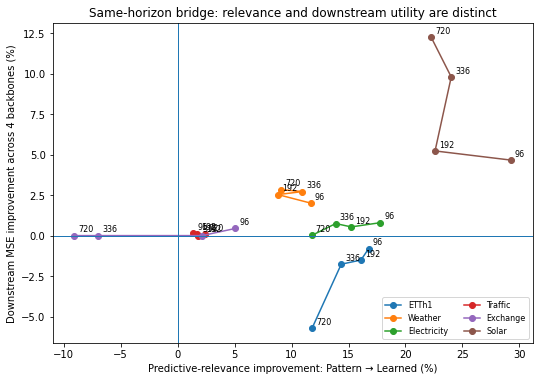

In [7]:
fig, ax = plt.subplots(figsize=(7.6, 5.4))

for dataset in DATASETS:
    g = bridge[
        bridge["Dataset"] == dataset
    ].sort_values("Horizon")

    ax.plot(
        g["RetrievalGain_pct"],
        g["DownstreamMeanGain_pct"],
        marker="o",
        label=dataset,
    )

    for _, r in g.iterrows():
        ax.annotate(
            str(int(r["Horizon"])),
            (
                r["RetrievalGain_pct"],
                r["DownstreamMeanGain_pct"],
            ),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )

ax.axhline(0.0, linewidth=1.0)
ax.axvline(0.0, linewidth=1.0)

ax.set_xlabel(
    "Predictive-relevance improvement: Pattern → Learned (%)"
)

ax.set_ylabel(
    "Downstream MSE improvement across 4 backbones (%)"
)

ax.set_title(
    "Same-horizon bridge: relevance and downstream utility are distinct"
)

ax.legend(
    ncol=2,
    fontsize=8,
)

fig.tight_layout()

fig.savefig(
    OUT_DIR / "full_24point_relevance_downstream_bridge.pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUT_DIR / "full_24point_relevance_downstream_bridge.png",
    dpi=240,
    bbox_inches="tight",
)

plt.show()


## 7. Regime-oriented figure

This companion plot uses the **Correct-vs.-Shuffled** gain rather than Pattern-vs.-Learned gain.
It asks whether query-specific relevance evidence predicts downstream utility.

This figure is useful if the paper wants to emphasize that even strong query-specific relevance
evidence is not sufficient for forecasting complementarity.


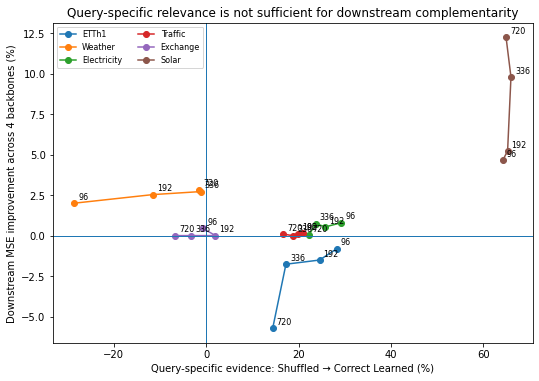

In [8]:
fig, ax = plt.subplots(figsize=(7.6, 5.4))

for dataset in DATASETS:
    g = bridge[
        bridge["Dataset"] == dataset
    ].sort_values("Horizon")

    ax.plot(
        g["QuerySpecificGain_pct"],
        g["DownstreamMeanGain_pct"],
        marker="o",
        label=dataset,
    )

    for _, r in g.iterrows():
        ax.annotate(
            str(int(r["Horizon"])),
            (
                r["QuerySpecificGain_pct"],
                r["DownstreamMeanGain_pct"],
            ),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )

ax.axhline(0.0, linewidth=1.0)
ax.axvline(0.0, linewidth=1.0)

ax.set_xlabel(
    "Query-specific evidence: Shuffled → Correct Learned (%)"
)

ax.set_ylabel(
    "Downstream MSE improvement across 4 backbones (%)"
)

ax.set_title(
    "Query-specific relevance is not sufficient for downstream complementarity"
)

ax.legend(
    ncol=2,
    fontsize=8,
)

fig.tight_layout()

fig.savefig(
    OUT_DIR / "query_specific_evidence_downstream_bridge.pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUT_DIR / "query_specific_evidence_downstream_bridge.png",
    dpi=240,
    bbox_inches="tight",
)

plt.show()


## 8. Paper-oriented compact tables


In [9]:
table24 = bridge[
    [
        "Dataset",
        "Horizon",
        "RetrievalGain_pct",
        "QuerySpecificGain_pct",
        "PriorGain_pct",
        "DownstreamMeanGain_pct",
        "DownstreamWins",
    ]
].copy()

for col in [
    "RetrievalGain_pct",
    "QuerySpecificGain_pct",
    "PriorGain_pct",
    "DownstreamMeanGain_pct",
]:
    table24[col] = table24[col].map(
        lambda v: f"{v:+.2f}"
    )

table24["DownstreamWins"] = table24["DownstreamWins"].map(
    lambda v: f"{int(v)}/4"
)

display(table24)

latex24 = table24.to_latex(
    index=False,
    escape=False,
)

(OUT_DIR / "full_24point_bridge_table.tex").write_text(
    latex24,
    encoding="utf-8",
)

table6 = dataset_mean[
    [
        "Dataset",
        "RetrievalGain_pct",
        "QuerySpecificGain_pct",
        "PriorGain_pct",
        "DownstreamMeanGain_pct",
        "DownstreamWins",
        "DownstreamTies",
        "DownstreamLosses",
    ]
].copy()

for col in [
    "RetrievalGain_pct",
    "QuerySpecificGain_pct",
    "PriorGain_pct",
    "DownstreamMeanGain_pct",
]:
    table6[col] = table6[col].map(
        lambda v: f"{v:+.2f}"
    )

display(table6)

latex6 = table6.to_latex(
    index=False,
    escape=False,
)

(OUT_DIR / "dataset_mean_bridge_table.tex").write_text(
    latex6,
    encoding="utf-8",
)

print("Saved LaTeX tables to:", OUT_DIR)


,Dataset,Horizon,RetrievalGain_pct,QuerySpecificGain_pct,PriorGain_pct,DownstreamMeanGain_pct,DownstreamWins
0,ETTh1,96,+16.77,+28.25,-1.87,-0.80,0/4
1,ETTh1,192,+16.09,+24.53,+6.56,-1.51,0/4
2,ETTh1,336,+14.36,+17.25,+12.82,-1.77,0/4
3,ETTh1,720,+11.80,+14.38,+14.19,-5.73,0/4
4,Weather,96,+11.70,-28.53,+71.77,+2.00,4/4
5,Weather,192,+8.80,-11.56,+66.75,+2.53,4/4
6,Weather,336,+10.94,-1.24,+63.04,+2.72,4/4
7,Weather,720,+9.09,-1.49,+58.82,+2.84,4/4
8,Electricity,96,+17.77,+29.24,+13.70,+0.80,4/4
9,Electricity,192,+15.23,+25.76,+13.33,+0.54,4/4


/tmp/ipykernel_109211/1317113129.py:29: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex24 = table24.to_latex(


,Dataset,RetrievalGain_pct,QuerySpecificGain_pct,PriorGain_pct,DownstreamMeanGain_pct,DownstreamWins,DownstreamTies,DownstreamLosses
0,ETTh1,+14.75,+21.11,+7.92,-2.45,0,0,16
1,Electricity,+14.66,+25.22,+14.10,+0.52,15,0,1
2,Exchange,-2.21,-2.17,+39.62,+0.11,1,15,0
3,Solar,+24.53,+65.06,-55.31,+7.99,16,0,0
4,Traffic,+1.81,+19.07,-3.24,+0.08,14,0,2
5,Weather,+10.13,-10.71,+65.10,+2.53,16,0,0


Saved LaTeX tables to: /data/dataset/strong_forecaster/full_long_horizon_relevance_downstream_bridge


/tmp/ipykernel_109211/1317113129.py:64: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex6 = table6.to_latex(


## 9. Reviewer-facing summary

The paper should not claim that relevance improvement causes forecasting improvement.

The stronger, directly supported statement is:

> Across the same four long-horizon targets used by the downstream study, future-supervised
> reranking improves candidate-level relevance in most dataset–horizon conditions. However,
> downstream forecasting utility remains strongly regime-dependent. In particular, ETTh1
> exhibits positive and statistically significant relevance gains at every horizon while historical
> memory degrades all four strong forecasters, demonstrating that relevance is not sufficient for
> complementarity.

Weather and Exchange provide a different distinction: candidate-global evidence can dominate
query-specific evidence, so the proposed learned relevance score need not be the best retrieval rule
even when Pattern similarity is inadequate.


In [10]:
print("=" * 116)
print("EXPERIMENT 40 — FULL LONG-HORIZON RELEVANCE → DOWNSTREAM BRIDGE")
print("=" * 116)

print(
    "Retrieval gain > 0:",
    int((bridge["RetrievalGain_pct"] > 0).sum()),
    "/24",
)

print(
    "Significant Pattern->Learned relevance gain:",
    int(bridge["Sig_RetrievalGain"].sum()),
    "/24",
)

print(
    "Significant Correct-vs-Shuffled evidence:",
    int(bridge["Sig_QuerySpecificGain"].sum()),
    "/24",
)

print()

for _, r in dataset_mean.iterrows():
    print(
        f"{r['Dataset']:12s} | "
        f"retrieval={r['RetrievalGain_pct']:+7.2f}% | "
        f"query-specific={r['QuerySpecificGain_pct']:+7.2f}% | "
        f"prior={r['PriorGain_pct']:+7.2f}% | "
        f"downstream={r['DownstreamMeanGain_pct']:+7.3f}% | "
        f"wins={int(r['DownstreamWins'])}/16"
    )

print("\nOutputs:")
for name in [
    "full_24point_bridge.csv",
    "bridge_correlations_descriptive.csv",
    "bridge_dataset_means.csv",
    "full_24point_relevance_downstream_bridge.pdf",
    "full_24point_relevance_downstream_bridge.png",
    "query_specific_evidence_downstream_bridge.pdf",
    "query_specific_evidence_downstream_bridge.png",
    "full_24point_bridge_table.tex",
    "dataset_mean_bridge_table.tex",
]:
    print(" -", OUT_DIR / name)


EXPERIMENT 40 — FULL LONG-HORIZON RELEVANCE → DOWNSTREAM BRIDGE
Retrieval gain > 0: 22 /24
Significant Pattern->Learned relevance gain: 19 /24
Significant Correct-vs-Shuffled evidence: 17 /24

ETTh1        | retrieval= +14.75% | query-specific= +21.11% | prior=  +7.92% | downstream= -2.452% | wins=0/16
Electricity  | retrieval= +14.66% | query-specific= +25.22% | prior= +14.10% | downstream= +0.523% | wins=15/16
Exchange     | retrieval=  -2.21% | query-specific=  -2.17% | prior= +39.62% | downstream= +0.110% | wins=1/16
Solar        | retrieval= +24.53% | query-specific= +65.06% | prior= -55.31% | downstream= +7.992% | wins=16/16
Traffic      | retrieval=  +1.81% | query-specific= +19.07% | prior=  -3.24% | downstream= +0.082% | wins=14/16
Weather      | retrieval= +10.13% | query-specific= -10.71% | prior= +65.10% | downstream= +2.526% | wins=16/16

Outputs:
 - /data/dataset/strong_forecaster/full_long_horizon_relevance_downstream_bridge/full_24point_bridge.csv
 - /data/dataset/stron